# Chi-Square Analysis

**Module 7: Categorical Outcomes** | Lean Six Sigma Data Analytics

---

## When to Perform a Chi-Square Analysis

Looking at the tree diagram for testing influence factors:

| Y Variable (CTQ) | X Variable (Influence Factor) | Method |
|------------------|-------------------------------|--------|
| Categorical | Categorical | **Chi-Square Analysis** |

If you have a Y variable (CTQ) that is **categorical** and an X variable (influence factor) that is also **categorical**, we have to perform a chi-square analysis.

---

## Steps of Chi-Square Analysis

| Step | Action |
|------|--------|
| 1 | Make a cross-tabulation |
| 2 | Interpret the p-value |

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for chi-square analysis!')

Ready for chi-square analysis!


---

## The Hospital Example

Assume you work at the surgical department called **A1**. Sometimes patients are placed at department **A4** because A1 is full.

There are three different specialists that work in this hospital department: **P**, **Q**, and **R**.

In one of the departments, patients stay longer than on the other departments. Could it be that the treating specialist is of influence?

**Question:** Do the specialists work equally frequently on both departments, or do they prefer one department over the other?

| Variable | Role | Type |
|----------|------|------|
| Department (A1, A4) | Y (CTQ) | Categorical |
| Specialist (P, Q, R) | X (influence factor) | Categorical |

Both variables are categorical, so we have to perform a **chi-square test**.

In [2]:
def load_hospital():
    """Load hospital data: Patient, Specialist, Department"""
    df = pd.read_excel(xlsx, sheet_name='Hospital', skiprows=7, header=0, usecols=[0, 1, 2])
    df.columns = ['Patient', 'Specialist', 'Department']
    return df.dropna()

hospital = load_hospital()
print('DATA LOADED')
print('=' * 50)
print(hospital.head(10))
print(f'\nTotal observations: {len(hospital)}')
print(f'\nSpecialists: {hospital["Specialist"].unique()}')
print(f'Departments: {hospital["Department"].unique()}')

DATA LOADED
   Patient Specialist Department
0        1          P         A1
1        2          P         A1
2        3          Q         A1
3        4          R         A1
4        5          Q         A1
5        6          P         A1
6        7          P         A1
7        8          Q         A1
8        9          R         A1
9       10          R         A4

Total observations: 269

Specialists: ['P' 'Q' 'R']
Departments: ['A1' 'A4']


---

## Step 1: Cross-Tabulation

The first step of chi-square analysis is to make a cross-tabulation.

In [3]:
# Create cross-tabulation (counts)
crosstab = pd.crosstab(hospital['Specialist'], hospital['Department'], margins=True, margins_name='All')

print('CROSS-TABULATION (Counts)')
print('=' * 50)
print(crosstab)

CROSS-TABULATION (Counts)
Department   A1  A4  All
Specialist              
P            81  17   98
Q            52  15   67
R            78  26  104
All         211  58  269


In [4]:
# Row percentages - percentage of patients per specialist in each department
row_pct = pd.crosstab(hospital['Specialist'], hospital['Department'], normalize='index') * 100

print('ROW PERCENTAGES')
print('=' * 50)
print('Percentage of each specialist\'s patients by department:')
print()
print(row_pct.round(1))
print()
print('Interpretation:')
print('For example, 82% of all patients treated by Specialist P were at department A1.')

ROW PERCENTAGES
Percentage of each specialist's patients by department:

Department    A1    A4
Specialist            
P           82.7  17.3
Q           77.6  22.4
R           75.0  25.0

Interpretation:
For example, 82% of all patients treated by Specialist P were at department A1.


In [5]:
# Column percentages - percentage of patients in each department by specialist
col_pct = pd.crosstab(hospital['Specialist'], hospital['Department'], normalize='columns') * 100

print('COLUMN PERCENTAGES')
print('=' * 50)
print('Percentage of each department\'s patients by specialist:')
print()
print(col_pct.round(1))
print()
print('Interpretation:')
print('For example, 38% of the patients treated in department A1 were treated by Specialist P.')

COLUMN PERCENTAGES
Percentage of each department's patients by specialist:

Department    A1    A4
Specialist            
P           38.4  29.3
Q           24.6  25.9
R           37.0  44.8

Interpretation:
For example, 38% of the patients treated in department A1 were treated by Specialist P.


In [6]:
# Combined view (like Minitab output)
print('COMPLETE CROSS-TABULATION')
print('=' * 50)
print()

# Get the basic crosstab without margins for calculations
ct = pd.crosstab(hospital['Specialist'], hospital['Department'])

for specialist in ct.index:
    print(f'Specialist {specialist}:')
    for dept in ct.columns:
        count = ct.loc[specialist, dept]
        row_p = row_pct.loc[specialist, dept]
        col_p = col_pct.loc[specialist, dept]
        print(f'  {dept}: Count={count}, Row%={row_p:.1f}%, Col%={col_p:.1f}%')
    print()

COMPLETE CROSS-TABULATION

Specialist P:
  A1: Count=81, Row%=82.7%, Col%=38.4%
  A4: Count=17, Row%=17.3%, Col%=29.3%

Specialist Q:
  A1: Count=52, Row%=77.6%, Col%=24.6%
  A4: Count=15, Row%=22.4%, Col%=25.9%

Specialist R:
  A1: Count=78, Row%=75.0%, Col%=37.0%
  A4: Count=26, Row%=25.0%, Col%=44.8%



---

## Step 2: Chi-Square Test and P-Value

Now that we have interpreted the cross-tabulation (Step 1), it's time to check if the results are significant (Step 2).

**Hypotheses:**
- **H₀ (Null):** The department is not related to the specialist (work is equally divided)
- **H₁ (Alternative):** At least one of the specialists has a preference for one of the departments

In [7]:
# Perform Chi-Square Test
ct = pd.crosstab(hospital['Specialist'], hospital['Department'])
chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print('CHI-SQUARE TEST')
print('=' * 50)
print(f'\nChi-Square Statistic: {chi2:.4f}')
print(f'Degrees of Freedom: {dof}')
print(f'P-Value: {p_value:.4f}')
print()
print('Expected Frequencies:')
expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print(expected_df.round(2))

CHI-SQUARE TEST

Chi-Square Statistic: 1.7834
Degrees of Freedom: 2
P-Value: 0.4100

Expected Frequencies:
Department     A1     A4
Specialist              
P           76.87  21.13
Q           52.55  14.45
R           81.58  22.42


In [8]:
print('INTERPRETATION')
print('=' * 50)
print(f'\nP-value: {p_value:.4f}')
print()
if p_value > 0.05:
    print('The p-value is much bigger than 0.05.')
    print()
    print('This means that we did NOT find significant results.')
    print('We cannot support our alternative hypothesis.')
    print('Therefore, we stick with our null hypothesis.')
    print()
    print('Conclusion:')
    print('The department where you are lying does NOT affect who treats you.')
    print('The division of work for each specialist is equally divided across departments.')
else:
    print('The p-value is smaller than 0.05.')
    print()
    print('This means that we found significant results.')
    print('We can support our alternative hypothesis.')
    print()
    print('Conclusion:')
    print('At least one specialist has a preference for one of the departments.')

INTERPRETATION

P-value: 0.4100

The p-value is much bigger than 0.05.

This means that we did NOT find significant results.
We cannot support our alternative hypothesis.
Therefore, we stick with our null hypothesis.

Conclusion:
The department where you are lying does NOT affect who treats you.
The division of work for each specialist is equally divided across departments.


---

## Visualization

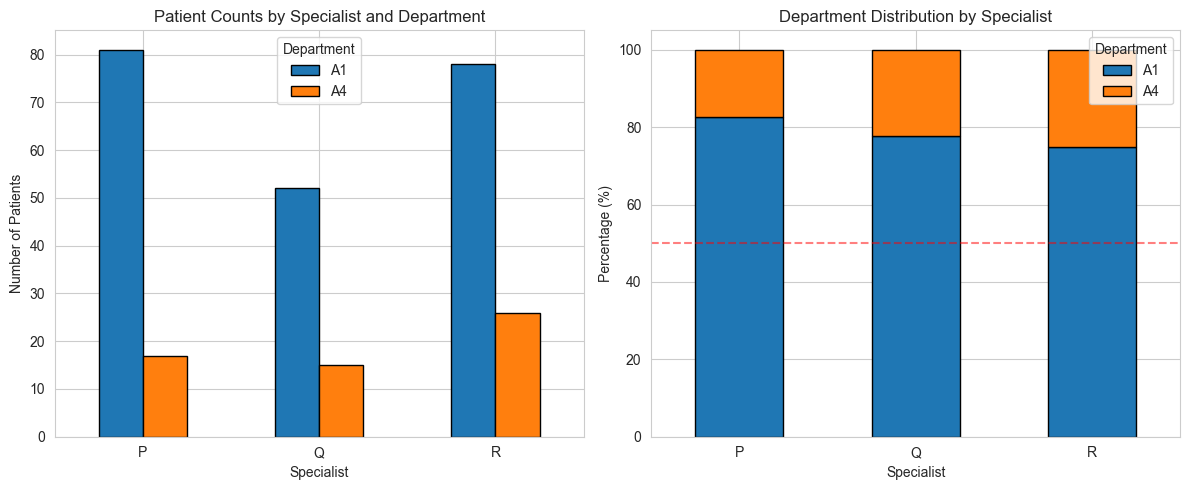

In [9]:
# Stacked bar chart showing distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Counts by specialist and department
ct.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_xlabel('Specialist')
axes[0].set_ylabel('Number of Patients')
axes[0].set_title('Patient Counts by Specialist and Department')
axes[0].legend(title='Department')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Row percentages (specialist preference)
row_pct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black')
axes[1].set_xlabel('Specialist')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Department Distribution by Specialist')
axes[1].legend(title='Department')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Equal split')

plt.tight_layout()
plt.show()

---

## Summary

**Chi-Square Analysis** is a suitable method if you have:
- A **categorical Y** (CTQ)
- A **categorical X** (influence factor)

| Step | Action | Purpose |
|------|--------|--------|
| 1 | Make a cross-tabulation | Understand the distribution of observations |
| 2 | Interpret the p-value | Check if results are significant |

**Hospital Example Result:**
- P-value > 0.05 → Not significant
- The department where a patient stays does not affect which specialist treats them
- Work is equally divided across departments for each specialist